# Notebook 4: Photon Statistics — Zero-Delay Correlations of Quantum Light

## What are we exploring?

The second-order coherence function $g^{(2)}(0)$ is a **central zero-delay
photon-correlation observable** in quantum optics. It classifies photon
statistics into three regimes:

| Regime | g²(0) | Statistics | Example |
|--------|-------|-----------| --------|
| Anti-bunching | < 1 | Sub-Poissonian | Fock states |
| Random | = 1 | Poissonian | Coherent states (lasers) |
| Bunching | > 1 | Super-Poissonian | Thermal light, squeezed vacuum |

In this notebook, we bring together all four fundamental quantum states and
compare their photon statistics in one unified analysis.

## Conventions used in this notebook

- Natural units are used for the oscillator algebra: $\hbar=1$.
- `N` is the Hilbert-space dimension, so photon numbers run from `0` to `N-1`.
- `g^{(2)}(0)` is a zero-delay correlation diagnostic, not a complete state classifier.
- Analytic tails and observable convergence are used for truncation checks; never trust `sum(P)` alone.

## Setup: Create All Four States with $\langle n \rangle \approx 3$

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import qutip

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from qo_utils import (
    photon_distribution,
    plot_photon_distribution,
    plot_wigner,
    wigner_normalization,
    mean_photon_number,
    photon_variance,
    compute_g2_zero,
    mandel_Q,
    coherent_tail,
    thermal_tail,
    squeezed_vacuum_tail,
    cutoff_from_tail,
    squeezed_wigner_extent,
)

plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16,
    'figure.figsize': (8, 5), 'figure.dpi': 150, 'savefig.dpi': 300,
    'text.usetex': False, 'mathtext.fontset': 'stix', 'font.family': 'STIXGeneral',
})

N = 80  # Required for the matched squeezed state with <n> = 3
a = qutip.destroy(N)

# Target: all states with <n> ~ 3 for fair comparison
n_target = 3

# 1. Fock state |3>
fock_state = qutip.basis(N, n_target)

# 2. Coherent state |alpha=sqrt(3)> -> <n> = 3
coherent_state = qutip.coherent(N, np.sqrt(n_target))

# 3. Squeezed vacuum with <n> = sinh^2(r) ~ 3 -> r = arcsinh(sqrt(3))
r_squeeze = np.arcsinh(np.sqrt(n_target))
assert squeezed_vacuum_tail(N, r_squeeze) < 1e-5, "Increase N for the matched squeezed state"
squeezed_state = qutip.squeeze(N, r_squeeze) * qutip.basis(N, 0)

# 4. Thermal state with n_bar = 3
thermal_state = qutip.thermal_dm(N, n_target)

states = {
    'Fock |3>': fock_state,
    'Coherent': coherent_state,
    'Squeezed': squeezed_state,
    'Thermal': thermal_state,
}

# Verify all have <n> ~ 3
print("=== State Verification ===\n")
for name, state in states.items():
    mn = mean_photon_number(state, a)
    print(f"{name:<15}: <n> = {mn:.3f}")

=== State Verification ===

Fock |3>       : <n> = 3.000
Coherent       : <n> = 3.000
Squeezed       : <n> = 3.000
Thermal        : <n> = 3.000


## THE Master Comparison Table

This table is the central deliverable of the single-mode analysis. All four
states have matched $\langle n \rangle \approx 3$, yet they have completely
different photon statistics.

In [2]:
print("=" * 76)
print("              MASTER COMPARISON: QUANTUM STATES OF LIGHT")
print("=" * 76)
print(f"{'State':<14} {'<n>':>6} {'Dn':>6} {'Dn/<n>':>7} "
      f"{'g2(0)':>8} {'Q':>7} {'Statistics':<14}")
print("-" * 76)

for name, state in states.items():
    mn = mean_photon_number(state, a)
    var = photon_variance(state, a)
    dn = np.sqrt(max(var, 0))
    g2 = compute_g2_zero(state, a)
    Q = mandel_Q(state, a)

    if Q < -0.01:
        stat_type = "Sub-Poisson"
    elif abs(Q) < 0.01:
        stat_type = "Poissonian"
    else:
        stat_type = "Super-Poisson"

    rel = dn/mn if mn > 0 else 0
    print(f"{name:<14} {mn:>6.2f} {dn:>6.2f} {rel:>7.2f} "
          f"{g2:>8.3f} {Q:>7.2f} {stat_type:<14}")

print("=" * 76)

              MASTER COMPARISON: QUANTUM STATES OF LIGHT
State             <n>     Dn  Dn/<n>    g2(0)       Q Statistics    
----------------------------------------------------------------------------
Fock |3>         3.00   0.00    0.00    0.667   -1.00 Sub-Poisson   
Coherent         3.00   1.73    0.58    1.000    0.00 Poissonian    
Squeezed         3.00   4.90    1.63    3.333    7.00 Super-Poisson 
Thermal          3.00   3.46    1.15    2.000    3.00 Super-Poisson 


## 4-Panel Photon Number Distributions

Side-by-side comparison of P(n) for all four state types. Notice the dramatically
different shapes — from a single spike (Fock) to the broad geometric
distribution (thermal).

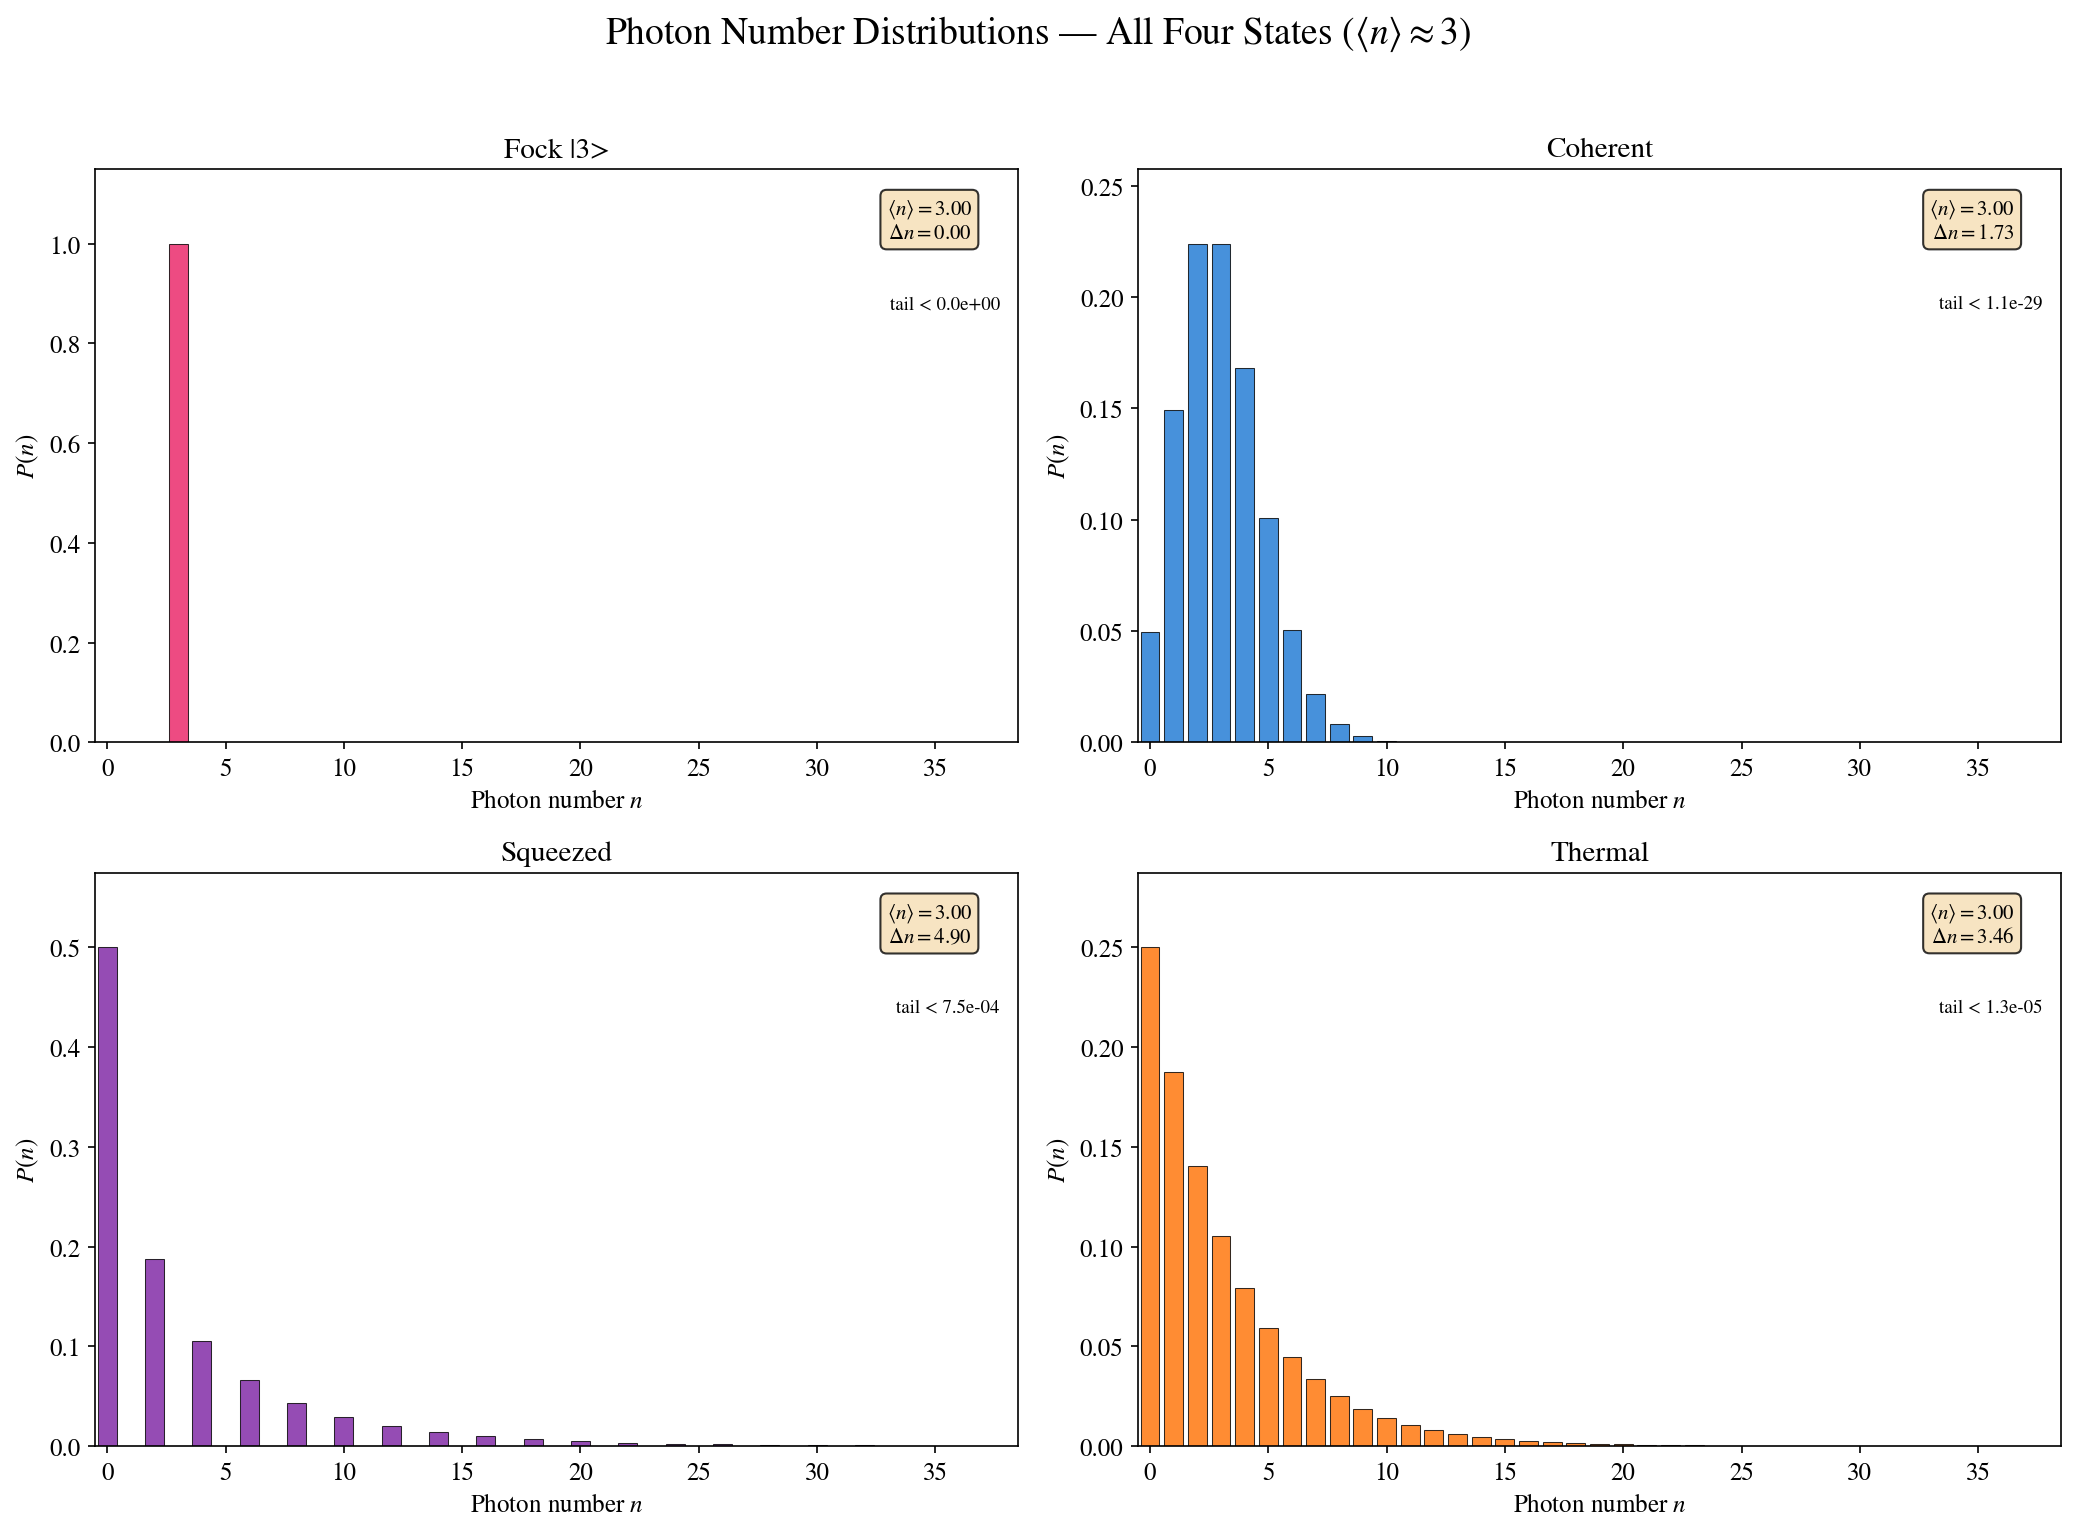

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['#E91E63', '#1976D2', '#7B1FA2', '#FF6F00']

coherent_cutoff = cutoff_from_tail(
    lambda cutoff: coherent_tail(cutoff, np.sqrt(n_target)),
    tolerance=1e-3, start=15,
)
squeezed_cutoff = cutoff_from_tail(
    lambda cutoff: squeezed_vacuum_tail(cutoff, r_squeeze),
    tolerance=1e-3, start=20,
)
thermal_cutoff = cutoff_from_tail(
    lambda cutoff: thermal_tail(cutoff, n_target),
    tolerance=1e-3, start=20,
)
n_plot_common = max(n_target + 3, coherent_cutoff, squeezed_cutoff, thermal_cutoff)

for idx, ((name, state), color) in enumerate(zip(states.items(), colors)):
    ax = axes[idx // 2, idx % 2]
    n_plot = n_plot_common
    if name.startswith('Fock'):
        tail_omitted = 0.0
    elif name.startswith('Coherent'):
        tail_omitted = coherent_tail(n_plot, np.sqrt(n_target))
    elif name.startswith('Squeezed'):
        tail_omitted = squeezed_vacuum_tail(n_plot, r_squeeze)
    else:
        tail_omitted = thermal_tail(n_plot, n_target)

    plot_photon_distribution(state, n_max=n_plot,
                             title=name, ax=ax, color=color, show_stats=True)
    ax.text(0.98, 0.78, f"tail < {tail_omitted:.1e}",
            transform=ax.transAxes, ha='right', va='top', fontsize=9)

plt.suptitle(r'Photon Number Distributions — All Four States ($\langle n \rangle \approx 3$)',
             fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'all_states_photon_distributions.png', bbox_inches='tight', dpi=300)
plt.savefig(FIG_DIR / 'all_states_photon_distributions.svg', bbox_inches='tight')
plt.show()

The four distributions show strikingly different shapes:
- **Fock** $|3\rangle$: single spike at $n=3$
- **Coherent**: bell-shaped Poisson centered at $n \approx 3$
- **Squeezed vacuum**: even-number only, peaked at $n=0$, long tail
- **Thermal**: geometrically decreasing from $n=0$